In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets

In [19]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print('Using PyTorch version:', torch.__version__, ' Device:', DEVICE)


Using PyTorch version: 2.5.1+cu121  Device: cuda


In [3]:
BATCH_SIZE = 32
EPOCHS = 10


In [45]:
train_dataset = datasets.CIFAR10(root = "../data/CIFAR_10",
                                  train = True,
                                  download = True,
                                  transform = transforms.ToTensor())


test_dataset = datasets.CIFAR10(root = "../data/CIFAR_10",
                                train = False,
                                transform = transforms.ToTensor())


train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                            batch_size = BATCH_SIZE,
                                            shuffle = True)


test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                          batch_size = BATCH_SIZE,
                                          shuffle = False)

Files already downloaded and verified


#### 이미지 확인

In [12]:
for (X_train, y_train) in train_loader:
    print('X_train:', X_train.size(), 'type:', X_train.type())
    print('y_train:', y_train.size(), 'type:', y_train.type())
    break

pltsize = 1
plt.figure(figsize=(10 * pltsize, pltsize))


X_train: torch.Size([32, 3, 32, 32]) type: torch.FloatTensor
y_train: torch.Size([32]) type: torch.LongTensor


<Figure size 1000x100 with 0 Axes>

<Figure size 1000x100 with 0 Axes>

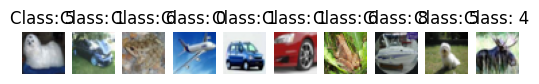

In [10]:
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.axis('off')
    plt.imshow(np.transpose(X_train[i], (1, 2, 0)))
    plt.title('Class: ' + str(y_train[i].item()))


In [34]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 8, kernel_size = 3, padding = 1)
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3, padding = 1)
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.fc1 = nn.Linear(8 * 8 * 16, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 10)
       
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
       
       # 평탄화
       # DNN에 넣기 위해 완전연결층
        x = x.view(-1, 8 * 8 * 16)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = F.log_softmax(x)
        return x


In [14]:
!pip install torchsummary

In [22]:
''' 7. Optimizer, Objective Function 설정하기 '''
model = CNN().to(DEVICE)
# optimizer = torch.optim.SGD(model.parameters(), lr = 0.01, momentum = 0.5)
# criterion = nn.CrossEntropyLoss()

print(model)
DEVICE

CNN(
  (conv1): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


device(type='cuda')

In [25]:
from torchsummary import summary
model = CNN()
summary(model,(3, 224, 224), device='cpu')
# summary(model,(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]         401,920
            Linear-2                  [-1, 256]         131,328
            Linear-3                   [-1, 10]           2,570
Total params: 535,818
Trainable params: 535,818
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 0.01
Params size (MB): 2.04
Estimated Total Size (MB): 2.62
----------------------------------------------------------------


In [26]:
model = CNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()

In [35]:
def train(model, train_loader, optimizer, log_interval):
    global output, label
    model.train()
    correct = 0
    train_loss = 0
    for batch_idx, (image, label) in enumerate(train_loader):
        # 입력 이미지 데이터 IMAGE
        # 정답 레이블 데이터 LABEL
        # GPU 활용하기 위해 
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()




        _, prediction = torch.max(output, dim=1 )
        # 정답을 맞춘 갯수
        # acc += sum(idx == label)
        correct += prediction.eq(label.view_as(prediction)).sum().item()




        if batch_idx % log_interval == 0:
            print("Train Epoch: {} [{}/{} ({:.0f}%)]\tTrain Loss: {:.6f}".format(
                EPOCHS, batch_idx * len(image),
                len(train_loader.dataset), 100. * batch_idx / len(train_loader),
                loss.item()))
           
    train_loss /= (len(train_loader.dataset) / BATCH_SIZE)
    train_accuracy = 100. * correct / len(train_loader.dataset)




    return train_loss, train_accuracy


In [36]:
def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0




    with torch.no_grad():
        for image, label in test_loader:
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim = True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()




    test_loss /= (len(test_loader.dataset) / BATCH_SIZE)
    test_accuracy = 100. * correct / len(test_loader.dataset)
    return test_loss, test_accuracy


In [37]:
loss_hist_train     = [0] * EPOCHS
accuracy_hist_train = [0] * EPOCHS
loss_hist_valid     = [0] * EPOCHS
accuracy_hist_valid = [0] * EPOCHS
for epoch in range(1, EPOCHS + 1):
    loss_, acc_ = train(model, train_loader, optimizer, log_interval = 200)
    loss_hist_train[epoch] = loss_
    accuracy_hist_train[epoch] = acc_
    test_loss, test_accuracy = evaluate(model, test_loader)
    loss_hist_valid[epoch] = test_loss
    accuracy_hist_valid[epoch] = test_accuracy
    print("\n[EPOCH: {}], \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, test_loss, test_accuracy))


RuntimeError: shape '[-1, 784]' is invalid for input of size 98304

In [39]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 8, kernel_size = 3, padding = 1)
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3, padding = 1)
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.fc1 = nn.Linear(8 * 8 * 16, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 10)
       
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
       
        x = x.view(-1, 8 * 8 * 16)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = F.log_softmax(x)
        return x


In [42]:
!pip install torchsummary
from torchsummary import summary
model = CNN()
summary(model, (3, 32,32), device='cpu')



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 32, 32]             224
         MaxPool2d-2            [-1, 8, 16, 16]               0
            Conv2d-3           [-1, 16, 16, 16]           1,168
         MaxPool2d-4             [-1, 16, 8, 8]               0
            Linear-5                   [-1, 64]          65,600
            Linear-6                   [-1, 32]           2,080
            Linear-7                   [-1, 10]             330
Total params: 69,402
Trainable params: 69,402
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.12
Params size (MB): 0.26
Estimated Total Size (MB): 0.39
----------------------------------------------------------------


/tmp/ipykernel_72883/1764710124.py:25: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.log_softmax(x)


In [43]:
model = CNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()


In [44]:
def train(model, train_loader, optimizer, log_interval):
    global output, label
    model.train()
    correct = 0
    train_loss = 0
    for batch_idx, (image, label) in enumerate(train_loader):
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()




        _, prediction = torch.max(output, dim=1 )
        # 정답을 맞춘 갯수
        # acc += sum(idx == label)
        correct += prediction.eq(label.view_as(prediction)).sum().item()




        if batch_idx % log_interval == 0:
            print("Train Epoch: {} [{}/{} ({:.0f}%)]\tTrain Loss: {:.6f}".format(
                EPOCHS, batch_idx * len(image),
                len(train_loader.dataset), 100. * batch_idx / len(train_loader),
                loss.item()))
           
    train_loss /= (len(train_loader.dataset) / BATCH_SIZE)
    train_accuracy = 100. * correct / len(train_loader.dataset)




    return train_loss, train_accuracy




def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0




    with torch.no_grad():
        for image, label in test_loader:
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim = True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()




    test_loss /= (len(test_loader.dataset) / BATCH_SIZE)
    test_accuracy = 100. * correct / len(test_loader.dataset)
    return test_loss, test_accuracy


In [ ]:
loss_hist_train     = [0] * EPOCHS
accuracy_hist_train = [0] * EPOCHS
loss_hist_valid     = [0] * EPOCHS
accuracy_hist_valid = [0] * EPOCHS
idx = 0
for epoch in range(1, EPOCHS + 1):
    idx
    loss_, acc_ = train(model, train_loader, optimizer, log_interval = 200)
    loss_hist_train[epoch] = loss_
    accuracy_hist_train[epoch] = acc_
    test_loss, test_accuracy = evaluate(model, test_loader)
    loss_hist_valid[epoch] = test_loss
    accuracy_hist_valid[epoch] = test_accuracy
    print("\n[EPOCH: {}], \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, test_loss, test_accuracy))



x_arr = np.arange(len(loss_hist_train[1:])) + 1    
#accuracy_hist_train
#loss_hist_valid [1:]  
#accuracy_hist_valid
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr,loss_hist_train[1:], '-o', label='Train loass' )
ax.plot(x_arr,loss_hist_valid[1:], '-o', label='Valid loass' )
ax.legend()


ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr,accuracy_hist_train[1:], '-o', label='Train accuracy' )
ax.plot(x_arr,accuracy_hist_valid[1:], '-o', label='Valid accuracy' )
ax.legend()
plt.show()


/tmp/ipykernel_72883/1764710124.py:25: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  x = F.log_softmax(x)


Train Epoch: 10 [0/50000 (0%)]	Train Loss: 2.314692
Train Epoch: 10 [6400/50000 (13%)]	Train Loss: 2.065631
Train Epoch: 10 [12800/50000 (26%)]	Train Loss: 1.857615
Train Epoch: 10 [19200/50000 (38%)]	Train Loss: 1.758304
Train Epoch: 10 [25600/50000 (51%)]	Train Loss: 1.691637
Train Epoch: 10 [32000/50000 (64%)]	Train Loss: 1.537117
Train Epoch: 10 [38400/50000 (77%)]	Train Loss: 1.654091
Train Epoch: 10 [44800/50000 (90%)]	Train Loss: 1.527321

[EPOCH: 1], 	Test Loss: 1.4840, 	Test Accuracy: 46.39 % 

Train Epoch: 10 [0/50000 (0%)]	Train Loss: 1.665913
Train Epoch: 10 [6400/50000 (13%)]	Train Loss: 1.464371
Train Epoch: 10 [12800/50000 (26%)]	Train Loss: 1.301218
Train Epoch: 10 [19200/50000 (38%)]	Train Loss: 1.506266
Train Epoch: 10 [25600/50000 (51%)]	Train Loss: 1.356743
Train Epoch: 10 [32000/50000 (64%)]	Train Loss: 1.621298
Train Epoch: 10 [38400/50000 (77%)]	Train Loss: 1.251909
Train Epoch: 10 [44800/50000 (90%)]	Train Loss: 1.319126

[EPOCH: 2], 	Test Loss: 1.3395, 	Test Ac

IndexError: list assignment index out of range

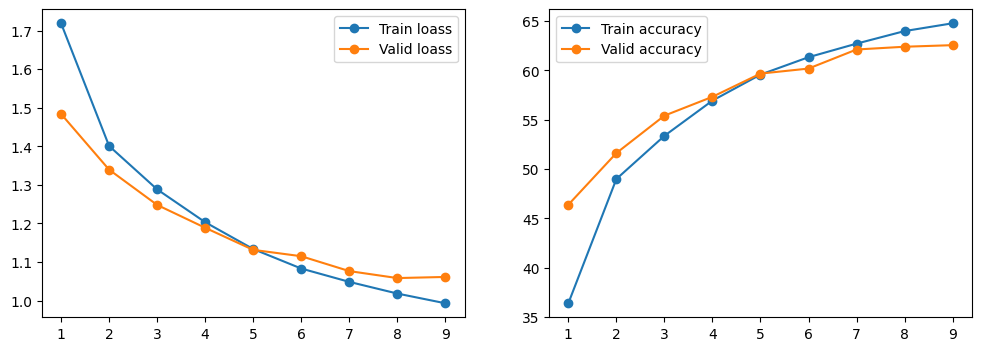

In [49]:

x_arr = np.arange(len(loss_hist_train[1:])) + 1    
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr,loss_hist_train[1:], '-o', label='Train loass' )
ax.plot(x_arr,loss_hist_valid[1:], '-o', label='Valid loass' )
ax.legend()


ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr,accuracy_hist_train[1:], '-o', label='Train accuracy' )
ax.plot(x_arr,accuracy_hist_valid[1:], '-o', label='Valid accuracy' )
ax.legend()
plt.show()